 # attention plot

 make the following 

 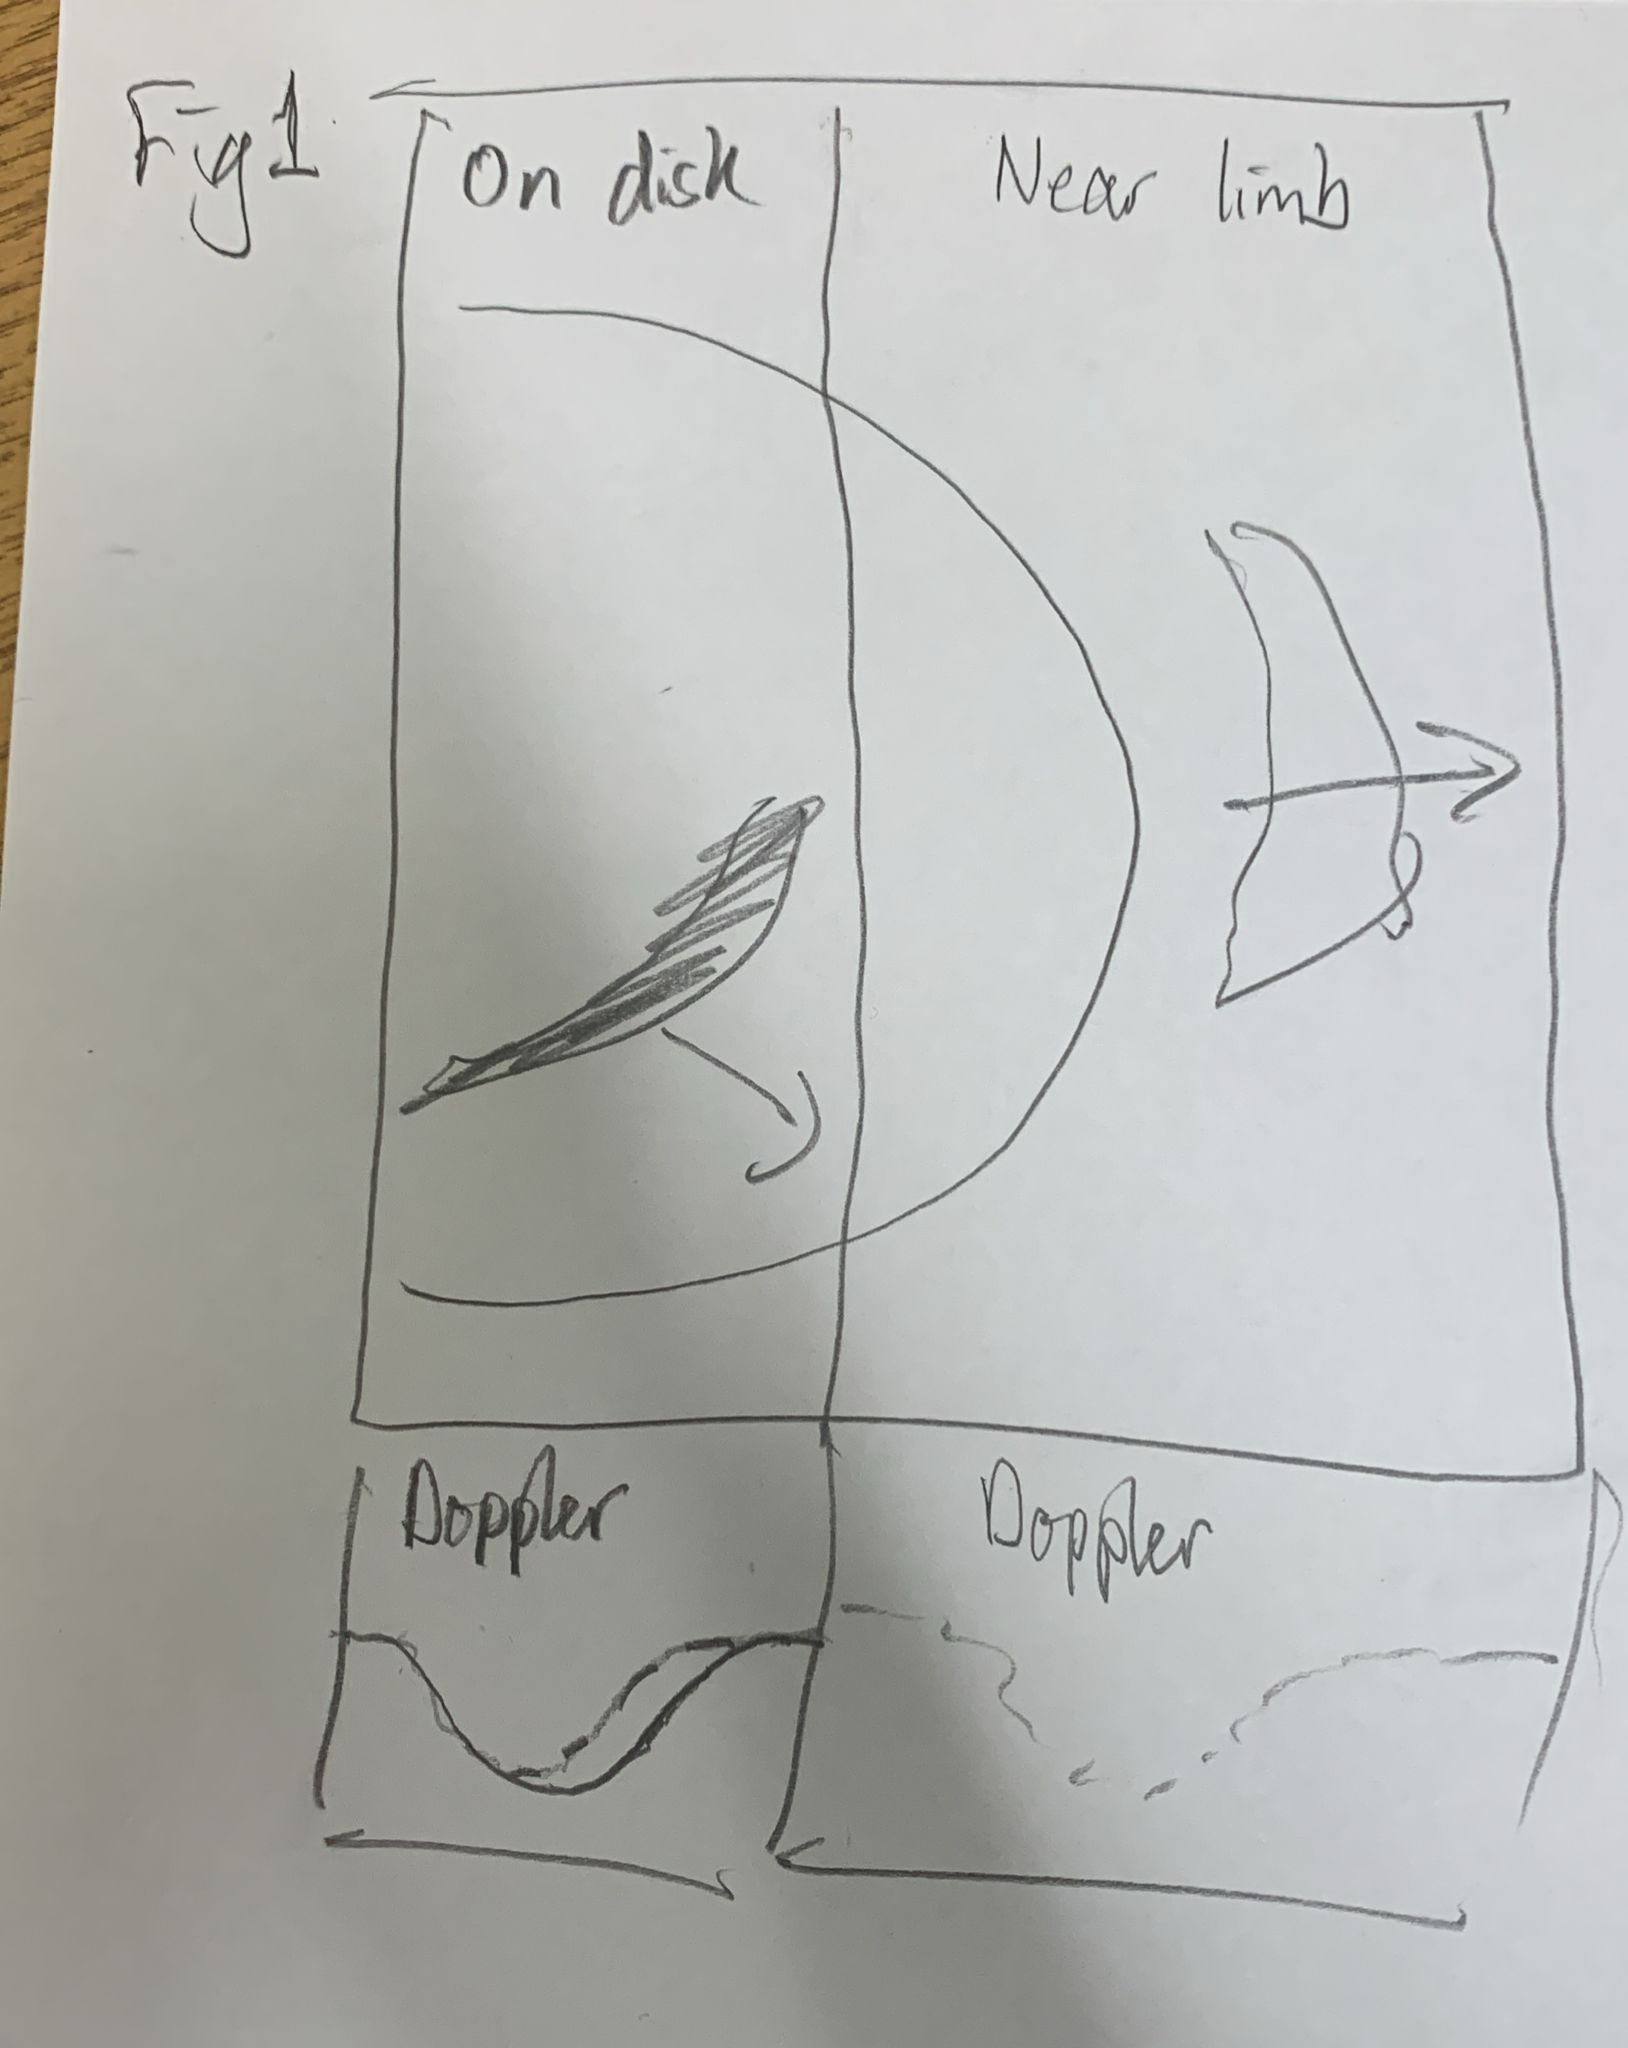

we will make this usting X9.3 or maybe the most on disk profile M1.8 (both have CME) we have together with helio viewer and the full off limb flare X8.2 that we have in our dataset.


In [1]:
import sys
sys.path.append('e:\solar flares\data\\2017-09-06')

import numpy as np
import matplotlib.pyplot as plt
import use_nessi as un
import use_nessi2 as un2
# import os
from importlib import reload

# from matplotlib import cm
# import matplotlib.cbook as cbook
# import matplotlib.colors as colors
# from scipy.interpolate import interp1d
from PIL import Image
from matplotlib import transforms



sr = solar_radius = 959.63
area_factor = 60**2/np.pi/sr**2

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_13932\2576846856.py:2: SyntaxWarning: invalid escape sequence '\s'
  sys.path.append('e:\solar flares\data\\2017-09-06')
e:\solar flares\data\2017-09-06\use_nessi.py:309: SyntaxWarning: invalid escape sequence '\A'
  da.plot_fit(data, model=model_atlas, theta0=mini['x'], titel="Fitting atlas to nessi ",labelx=" $wavelength [\AA]$",
e:\solar flares\data\2017-09-06\use_nessi.py:980: SyntaxWarning: invalid escape sequence '\A'
  da.plot_fit(data, model=f_nessi_clv, theta0=mini['x'], titel="fitting Nessi to sst data ",labelx=" $wavelength [\AA]$",
e:\solar flares\data\2017-09-06\use_nessi.py:1732: SyntaxWarning: invalid escape sequence '\D'
  print(f'The maximal signal to noise ratio for the {criterion} criterion is if the interval is of width $\Delta x={Deltas[i]}\AA$.')
e:\solar flares\data\2017-09-06\use_nessi.py:1732: SyntaxWarning: invalid

In [21]:
lines = ["CaII17", "CaIR17a"]

# reload(un)
    
def get_data(lines):
    data = un.load_for_further_analysis(lines)
    for line in lines:
        if "CaK" in line:
            un2.disgard_cont_point(line, data)
    
    return data 

data = get_data(lines)

def get_Nessi(name_of_line):
    wav_nessi, fov_nessi, saas_nessi = data[f"nessi_{name_of_line}"]
    return wav_nessi, fov_nessi, saas_nessi
    
def get_FOV(name_of_line):
    time = data[f"TIME_{name_of_line}"]

    FOV = data[f"FOV_{name_of_line}"]
    wav_qs, qs_spec, std_qs = data[f"quiet_sun_{name_of_line}"]
    return wav_qs, time, FOV

def get_composed_spec(name_of_line):
    wav, DFD, time, line, std  = un2.difference_FD_data(name_of_line, data, quiet_sun_subtraction=False, num=100,area_factor=2.5*60**2/np.pi/959.63**2, add_noise=False)
    return wav , DFD + line 

F=1
def plot_Nessi(ax, line):
    global F
    wav_nessi, fov_nessi, saas_nessi = get_Nessi(line)
    ax.plot(wav_nessi, fov_nessi, label="FOV NESSI", linewidth=3)
    ax.plot(wav_nessi, saas_nessi * F, label="SAAS NESSI")
    

def plot_FOV(ax, line, frame):
    wav_qs, time, FOV = get_FOV(line)
    if 'Ha' in line:
        plot_pixel(ax, wav_qs)
        frame=30
    else:
        ax.plot(wav_qs, FOV[frame] * F, label="flare profile")

    wav , full = get_composed_spec(line)
    # ax.plot(wav, full[frame], '--', label="scaled flare")

    ax.set_title(f'{latex_name(line)}') # at {un.time_hulp(time[frame] + un.hulp_time("11:53:00"))}')
    
    
def plot_pixel(ax,wav):
    P = [1.2570316, 1.6008017, 1.8352637, 2.4310818, 2.5809662, 2.6837046, 2.6218596, 2.5489583, 2.5635176, 2.4375014, 2.269423, 2.0090542, 1.3497262]
    ax.plot(wav, P, label="Pixel SST")
    
    
def latex_name(name): 
    names = {"Ha":r"$\rm{H}\alpha$", 
             "CaK":r'$\rm{Ca}~\rm{II}~\rm{K}$', 
             "CaI":r'$\rm{Ca}~\rm{II}~8542~\rm{\AA}$', 
             "Fe6173":r'$\rm{Fe}~I~6173~\rm{\AA}$', 
             "Hbeta":r'$\rm{H}\beta$', 
             "CaK(2)":r'$\rm{Ca}~\rm{II}~\rm{H}$', 
             "He":r'$\rm{He}~I~5876\rm{\AA}$'}
    for k in names.keys():
        if k in name:
            return names[k]

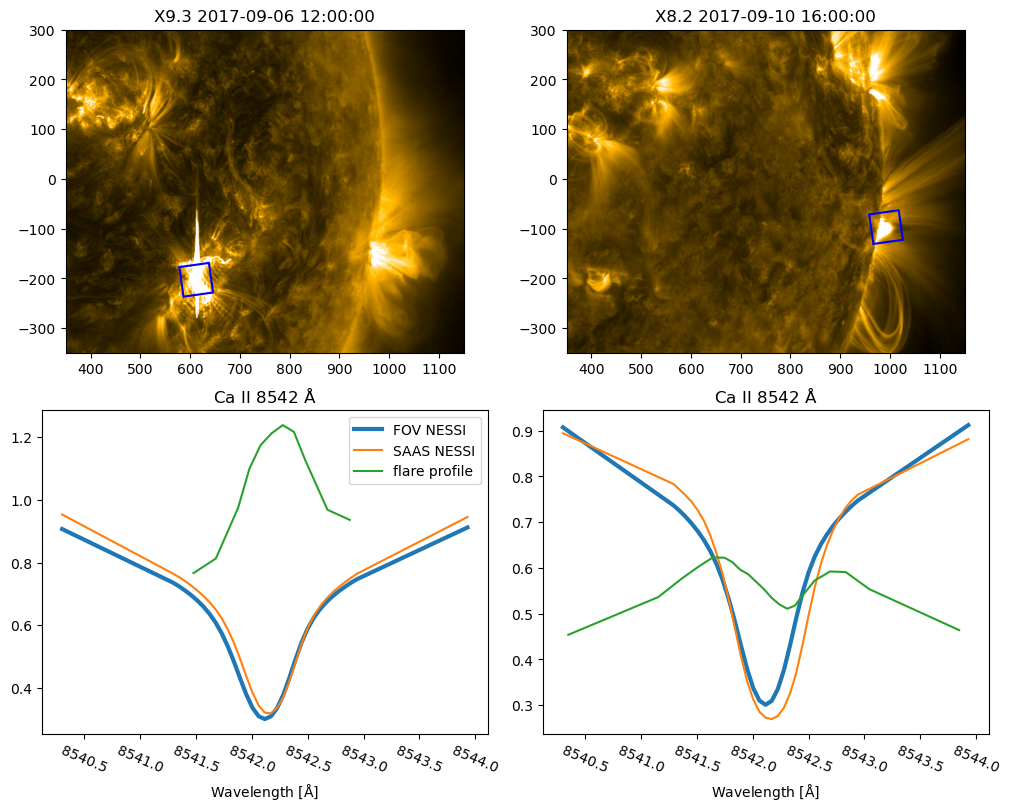

In [24]:

# make figure
rows = 2
cols = 2
t = 1
fig, ax = plt.subplots(rows, cols, figsize=(5*t*cols,4*t*rows), constrained_layout=True)

title='Attention plot'

# fig.suptitle(title, fontsize=20)
# 1707 x 825
frame = 5
F=1
for i, line in enumerate(lines):
    plot_Nessi(ax[1,i], line)
    plot_FOV(ax[1,i], line, frame)
    # ax[1,i].set_ylim(0, 4.45)
    ax[1,i].set_xlabel(r'Wavelength [$\rm\AA$]')
    ax[1,i].tick_params(axis='x', which='major', rotation=-23)  # Rotate x-ticks by 45 degrees  
    F=2
# ax[2].set_ylabel('Relative Intensity')
ax[1,0].legend()
ax[0,0].set_title('X9.3 2017-09-06 12:00:00')
ax[0,1].set_title('X8.2 2017-09-10 16:00:00')


import matplotlib.image as mpimg  # Import the image module
img1 = mpimg.imread('E:\\CME_distribution\\Figures\\2017_09_06_12_00_00_AIA_171.png')  
img2 = mpimg.imread('E:\\CME_distribution\\Figures\\2017_09_10_16_00_00_AIA_171.png')  

# Display the image in the first subplot
r = 1056
ax[0,0].imshow(img1, extent=(167, 1168, -419, 344)) #,cmap='gray')
ax[0,1].imshow(img2, extent=(167, 1168, -419, 344)) #,cmap='gray')
# ax[0].set_title(r'2017/09/06 11:55:00 UT GONG')
# ax[0].axis('off')  # Turn off axis labels and ticks
# ax[0].set_xlabel('[arcsec]')
# ax[0].set_ylabel('[arcsec]')
# ax[0].set_ylim(-960, 960)
# ax[0].set_xlim(-960, 960)



import matplotlib.patches as patches
import matplotlib.transforms as transforms

# Rectangle parameters, FOV 1
rect_x = 513+35  # X-coordinate of the rectangle's bottom-left corner
rect_y = -216-100  # Y-coordinate of the rectangle's bottom-left corner
rect_width = 60  # Width of the rectangle
rect_height = 60  # Height of the rectangle
angle = 8    # Rotation angle in degrees (counter-clockwise)

# Create a Rectangle patch
rect = patches.Rectangle((rect_x, rect_y), rect_width, rect_height, linewidth=1.5, edgecolor='blue', facecolor='none')

# Create a Transform object for rotation
transform = transforms.Affine2D().rotate_deg(angle)

# Add the transformation to the rectangle
rect.set_transform(transform + ax[0,0].transData) 

# Add the rectangle to the axes
ax[0,0].add_patch(rect)

# Rectangle parameters, FOV 2
rect_x = 959-20  # X-coordinate of the rectangle's bottom-left corner
rect_y = -144-120  # Y-coordinate of the rectangle's bottom-left corner
rect_width = 60  # Width of the rectangle
rect_height = 60  # Height of the rectangle
angle = 8    # Rotation angle in degrees (counter-clockwise)

# Create a Rectangle patch
rect = patches.Rectangle((rect_x, rect_y), rect_width, rect_height, linewidth=1.5, edgecolor='blue', facecolor='none')

# Create a Transform object for rotation
transform = transforms.Affine2D().rotate_deg(angle)

# Add the transformation to the rectangle
rect.set_transform(transform + ax[0,1].transData) 

# Add the rectangle to the axes
ax[0,1].add_patch(rect)

for i in [0,1]:
    ax[0, i].set_xlim(350, 1150) 
    ax[0,i].set_ylim(-350, 300)


plt.show()

fig.savefig("Figures/Attention_plot")

 